## Create an ensemble model using the generated heatmaps

Current weights used are set as an equal amongst the 4 window sizes

In [10]:
import os
import math
import time
import cv2
import csv
import ast
import shutil
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from skimage.feature import hog
from skimage.color.adapt_rgb import adapt_rgb, each_channel, hsv_value
from skimage import filters

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn import tree

from scipy.ndimage.measurements import label


%matplotlib inline

C:\Users\Lee Le Xuan\AppData\Local\Temp\ipykernel_37820\3320984788.py:22: DeprecationWarning: Please import `label` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.measurements import label


In [11]:
def apply_dynamic_threshold(heatmap, percentile=90):
  """
  Applies a dynamic threshold based on the heatmap percentile.

  Args:
      heatmap: 2D array representing the heatmap intensity.
      percentile (optional): Percentile value (e.g., 90) to use for thresholding.

  Returns:
      thresholded_heatmap: Heatmap with values below the threshold set to 0.
  """
  threshold = np.percentile(heatmap, percentile)
  heatmap[heatmap <= threshold] = 0
  
  return heatmap

def draw_labeled_bboxes(img, labels):
    """
        Draw the boxes on the detected microglias
    """
    for i in range(1, labels[1]+1):
        # Find pixels with each microglia label value
        nonzero = (labels[0] == i).nonzero()
        # Identify x and y values of those pixels
        nonzeroy = np.array(nonzero[0])
        nonzerox = np.array(nonzero[1])
        # Define a bounding box based on min/max x and y
        bbox = ((np.min(nonzerox), np.min(nonzeroy)), (np.max(nonzerox), np.max(nonzeroy)))
        cv2.rectangle(img, bbox[0], bbox[1], (255, 0, 0), 6)
    return img

def plot_img(img, show_stages=False, label=""):
    """
        plot image
    """
    if show_stages:
        print("############################# "+ label +" ##################################")
        plt.imshow(img, cmap='gray')
        plt.show()

13_s46_heatmap_100.npy
(2048, 2048)
13_s46_heatmap_64.npy
(2048, 2048)
13_s46_heatmap_80.npy
(2048, 2048)
############################# After threshold ##################################


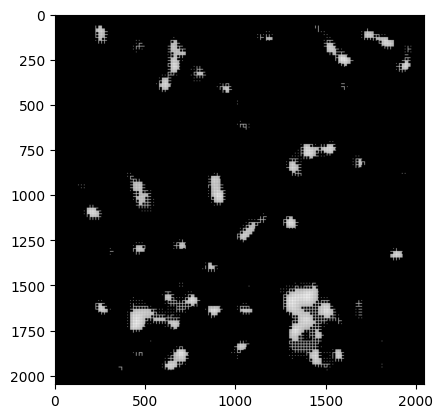

############################# Final Result ##################################


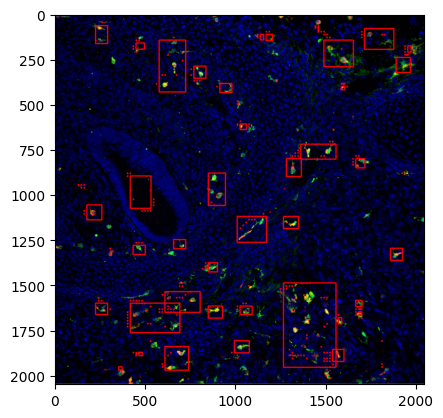

14_s47_heatmap_100.npy
(2048, 2048)
14_s47_heatmap_64.npy
(2048, 2048)
14_s47_heatmap_80.npy
(2048, 2048)
############################# After threshold ##################################


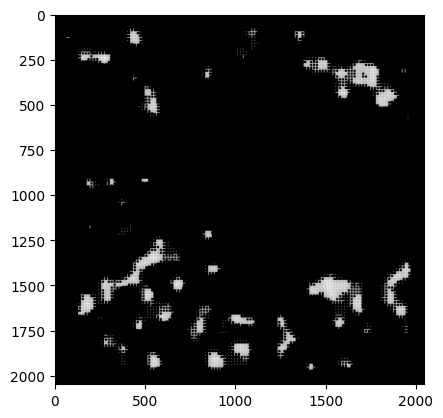

############################# Final Result ##################################


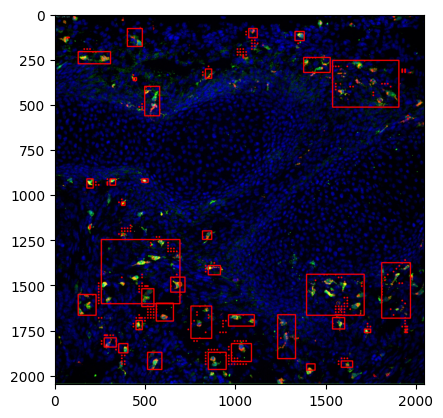

In [12]:
def ensemble_heatmap(heatmap_dir, test_dir, threshold):
    for img_name in os.listdir(heatmap_dir):
        img = mpimg.imread(test_dir + "/" + img_name + ".jpg")
        new_heatmap = np.zeros_like(img[:,:,0]).astype(float)
        count = 0
        heatmapimg_path = os.path.join(heatmap_dir, img_name)
        for heatmap in os.listdir(heatmapimg_path):
            print(heatmap)
            heatmap_filepath = os.path.join(heatmapimg_path, heatmap)
            loaded_heatmap = np.load(heatmap_filepath)[0]
            print(loaded_heatmap.shape)
            new_heatmap += loaded_heatmap
            count += 1
        new_heatmap = new_heatmap/count
        new_heatmap = apply_dynamic_threshold(new_heatmap, threshold)
        plot_img(new_heatmap, True, "After threshold")
        
        labels = label(new_heatmap)
        out_img = draw_labeled_bboxes(np.copy(img), labels)

        plot_img(out_img, True, "Final Result")
        
    return
    
test_dir = "test_images"
heatmap_dir = "Heatmaps"
ensemble_heatmap(heatmap_dir, test_dir, 95)


In [16]:
def confusion_matrix(tp, fp, fn):
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    # accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1_score = 2 * (precision * recall) / (precision + recall)
    
    print("Precision: " + str(precision))
    print("Recall: " + str(recall))
    # print("Accuracy: " + accuracy)
    print("F1-score: " + str(f1_score))
    
    
    
print("13_64")
confusion_matrix(57, 0, 66)
print("13_80")
confusion_matrix(66, 8, 57)
print("13_100")
confusion_matrix(76, 11, 47)
print("13_ensemble")
confusion_matrix(71, 4, 52)


print("/////////////////////////////////////////////")
print("14_64")
confusion_matrix(67, 0, 55)
print("14_80")
confusion_matrix(73, 3, 49)
print("14_100")
confusion_matrix(88, 14, 34)
print("14_ensemble")
confusion_matrix(81, 4, 41)

print("/////////////////////////////////////////////")
print("both_64")
confusion_matrix(124, 0, 121)
print("both_80")
confusion_matrix(139, 11, 106)
print("both_100")
confusion_matrix(164, 25, 78)
print("both_ensemble")
confusion_matrix(152, 8, 93)




13_64
Precision: 1.0
Recall: 0.4634146341463415
F1-score: 0.6333333333333334
13_80
Precision: 0.8918918918918919
Recall: 0.5365853658536586
F1-score: 0.6700507614213198
13_100
Precision: 0.8735632183908046
Recall: 0.6178861788617886
F1-score: 0.7238095238095238
13_ensemble
Precision: 0.9466666666666667
Recall: 0.5772357723577236
F1-score: 0.7171717171717171
/////////////////////////////////////////////
14_64
Precision: 1.0
Recall: 0.5491803278688525
F1-score: 0.7089947089947091
14_80
Precision: 0.9605263157894737
Recall: 0.5983606557377049
F1-score: 0.7373737373737373
14_100
Precision: 0.8627450980392157
Recall: 0.7213114754098361
F1-score: 0.7857142857142857
14_ensemble
Precision: 0.9529411764705882
Recall: 0.6639344262295082
F1-score: 0.7826086956521738
/////////////////////////////////////////////
both_64
Precision: 1.0
Recall: 0.5061224489795918
F1-score: 0.6720867208672087
both_80
Precision: 0.9266666666666666
Recall: 0.5673469387755102
F1-score: 0.7037974683544304
both_100
Precis